In [14]:
import os
os.environ['STPSF_PATH'] = '/blue/adamginsburg/t.yoo/from_red/stpsf-data'
import stpsf as webbpsf

webbpsf.conf.STPSF_PATH = '/blue/adamginsburg/t.yoo/from_red/stpsf-data'

# Continue with other imports
from webbpsf.utils import to_griddedpsfmodel
import glob
from astropy.table import QTable, vstack
from jwst.datamodels import dqflags
import time
import numpy
import crowdsource
import regions
import numpy as np
from functools import cache
from astropy.convolution import convolve, Gaussian2DKernel, interpolate_replace_nans, convolve_fft
from astropy.table import Table
from astropy.coordinates import SkyCoord
from astropy.visualization import simple_norm
from astropy.modeling.fitting import LevMarLSQFitter
from astropy import wcs
from astropy import table
from astropy import stats
from astropy import units as u
from astropy.nddata import NDData
from astropy.io import fits
from scipy import ndimage
import requests
import requests.exceptions
import urllib3
import urllib3.exceptions
from photutils.detection import DAOStarFinder
from crowdsource import crowdsource_base
from crowdsource.crowdsource_base import fit_im, psfmod
from dust_extinction.averages import RL85_MWGC, CT06_MWLoc
from astropy.convolution import convolve, Gaussian2DKernel, interpolate_replace_nans, convolve_fft
from jwst.datamodels import dqflags
try:
    # version >=1.7.0, doesn't work: the PSF is broken (https://github.com/astropy/photutils/issues/1580?)
    from photutils.psf import PSFPhotometry, IterativePSFPhotometry, SourceGrouper
except:
    # version 1.6.0, which works
    from photutils.psf import BasicPSFPhotometry as PSFPhotometry, IterativelySubtractedPSFPhotometry as IterativePSFPhotometry, DAOGroup as SourceGrouper
try:
    from photutils.background import MMMBackground, MADStdBackgroundRMS, MedianBackground, Background2D, LocalBackground
except:
    from photutils.background import MMMBackground, MADStdBackgroundRMS, MedianBackground, Background2D
    from photutils.background import MMMBackground as LocalBackground
import matplotlib.pyplot as plt
from regions import PixCoord, CirclePixelRegion
from astroquery.svo_fps import SvoFps
image_filenames ={
    "f140m": "/orange/adamginsburg/jwst/w51/F140M/pipeline/jw06151-o001_t001_nircam_clear-f140m-merged_i2d.fits",
    "f162m": "/orange/adamginsburg/jwst/w51/F162M/pipeline/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/w51/F182M/pipeline/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/F187N/pipeline/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/F210M/pipeline/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f335m": "/orange/adamginsburg/jwst/w51/F335M/pipeline/jw06151-o001_t001_nircam_clear-f335m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/F360M/pipeline/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/F405N/pipeline/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/F410M/pipeline/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits", # weird, the filename is different from what is downloaded with the STScI pipeline...
    "f480m": "/orange/adamginsburg/jwst/w51/F480M/pipeline/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
    "f560w": "/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_i2d.fits",
    "f770w": "/orange/adamginsburg/jwst/w51/F770W/pipeline/jw06151-o002_t001_miri_f770w_i2d.fits",
    "f1000w": "/orange/adamginsburg/jwst/w51/F1000W/pipeline/jw06151-o002_t001_miri_f1000w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/w51/F1280W/pipeline/jw06151-o002_t001_miri_f1280w_i2d.fits",
    "f1500w": "/orange/adamginsburg/jwst/w51/F1500W/pipeline/jw06151-o002_t001_miri_f1500w_i2d.fits",
    "f2100w": "/orange/adamginsburg/jwst/w51/F2100W/pipeline/jw06151-o002_t001_miri_f2100w_i2d.fits",
   
}
def get_mag(flux, ww, filtername='f140m' ):
    print(ww.proj_plane_pixel_area())
    
    flux= (flux * u.MJy/u.sr * ww.proj_plane_pixel_area()).to(u.Jy)
   # eflux_jy = (eflux_jy * u.MJy/u.sr *  ww.proj_plane_pixel_area()).to(u.Jy)

    jfilts = SvoFps.get_filter_list('JWST')
    jfilts.add_index('filterID')
    wav = int(filtername[1:-1])

    zeropoint_ab = 3631 * u.Jy  # Default to AB magnitude zero point
 
    if wav < 500:

        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/NIRCam.{filtername.upper()}']['ZeroPoint'], u.Jy)
    else:
        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/MIRI.{filtername.upper()}']['ZeroPoint'], u.Jy)
   
    #abmag = -2.5 * np.log10(flux / zeropoint_ab) * u.mag
    #abmag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    vegamag = -2.5 * np.log10(flux / zeropoint_vega) * u.mag
    #vegamag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    return  vegamag


class WrappedPSFModel(crowdsource.psf.SimplePSF):
    """
    wrapper for photutils GriddedPSFModel
    """
    def __init__(self, psfgridmodel, stampsz=19):
        self.psfgridmodel = psfgridmodel
        self.default_stampsz = stampsz

    def __call__(self, col, row, stampsz=None, deriv=False):

        if stampsz is None:
            stampsz = self.default_stampsz

        parshape = numpy.broadcast(col, row).shape
        tparshape = parshape if len(parshape) > 0 else (1,)

        # numpy uses row, column notation
        rows, cols = np.indices((stampsz, stampsz)) - (np.array([stampsz, stampsz])-1)[:, None, None] / 2.

        # explicitly broadcast
        col = np.atleast_1d(col)
        row = np.atleast_1d(row)
        #rows = rows[:, :, None] + row[None, None, :]
        #cols = cols[:, :, None] + col[None, None, :]

        # photutils seems to use column, row notation
        # only works with photutils <= 1.6.0 - but is wrong there
        #stamps = self.psfgridmodel.evaluate(cols, rows, 1, col, row)
        # it returns something in (nstamps, row, col) shape
        # pretty sure that ought to be (col, row, nstamps) for crowdsource

        # andrew saydjari's version here:
        # it returns something in (nstamps, row, col) shape
        stamps = []
        for i in range(len(col)):
            # the +0.5 is required to actually center the PSF (empirically)
            #stamps.append(self.psfgridmodel.evaluate(cols+col[i]+0.5, rows+row[i]+0.5, 1, col[i], row[i]))
            # the above may have been true when we were using (incorrectly) offset PSFs
            stamps.append(self.psfgridmodel.evaluate(cols+col[i], rows+row[i], 1, col[i], row[i]))

        stamps = np.array(stamps)

        # for oversampled stamps, they may not be normalized
        stamps /= stamps.sum(axis=(1,2))[:,None,None]
        # this is evidently an incorrect transpose
        #stamps = np.transpose(stamps, axes=(0,2,1))

        if deriv:
            dpsfdrow, dpsfdcol = np.gradient(stamps, axis=(1, 2))

        ret = stamps
        if parshape != tparshape:
            ret = ret.reshape(stampsz, stampsz)
            if deriv:
                dpsfdrow = dpsfdrow.reshape(stampsz, stampsz)
                dpsfdcol = dpsfdcol.reshape(stampsz, stampsz)
        if deriv:
            ret = (ret, dpsfdcol, dpsfdrow)

        return ret

    def render_model(self, col, row, stampsz=None):
        """
        this function likely does nothing?
        """
        if stampsz is not None:
            self.stampsz = stampsz

        rows, cols = np.indices(self.stampsz, dtype=float) - (np.array(self.stampsz)-1)[:, None, None] / 2.

        return self.psfgridmodel.evaluate(cols, rows, 1, col, row).T.squeeze()




def inject_synthetic_stars(img):
    # use psf_grid in stpsf package to inject synthetic stars
    pass


def get_psf_model(filtername, proposal_id, field,
                  module,
                  obsdate=None,
                  target='w51',
                  stampsz=19,
                  oversample=1,
                  basepath='/orange/adamginsburg/jwst/'):
    """
    Return two types of PSF model, the first for DAOPhot and the second for Crowdsource
    """
    if filtername.upper() in ['F140M', 'F150W', 'F162M', 'F164N', 'F182M', 'F187N',
                              'F200W', 'F210M', 'F212N', 'F250M', 'F300M', 'F322W2',
                              'F335M', 'F356W', 'F360M', 'F410M', 'F430M', 'F444W', 'F405N',
                              'F460M', 'F466N', 'F480M']:
        instrument = 'NIRCam'
    else:
        instrument = 'MIRI'

    basepath = f'{basepath}/{target}'
    psf_dir = "."

    psf_fn = (
        f"{psf_dir}/"
        f"{instrument.lower()}_{module}_{filtername.lower()}_fovp101_samp4_npsf16.fits"
    )
    print('psf_fn', psf_fn, flush=True)
    if os.path.exists(psf_fn):
        print(f"Loading cached PSF grid: {psf_fn}", flush=True)
        grid = to_griddedpsfmodel(psf_fn)
        psf_model = WrappedPSFModel(grid, stampsz=stampsz)
        
    else:
        
        has_downloaded = False
        ntries = 0
        
        while not has_downloaded:
            ntries += 1
            try:
                print("Attempting to download WebbPSF data", flush=True)
                if filtername.upper() in ['F140M', 'F150W', 'F162M', 'F164N', 'F182M', 'F187N',
                                  'F200W', 'F210M', 'F212N', 'F250M', 'F300M', 'F322W2', 'F405N',
                                  'F335M', 'F356W', 'F360M', 'F410M', 'F430M', 'F444W',
                                  'F460M', 'F466N', 'F480M']:
                    nrc = webbpsf.NIRCam()
                    #print('nrc=webbpsf.NIRCam()', flush=True)
                else:
                    nrc = webbpsf.MIRI()
                   # print('nrc=webbpsf.MIRI()', flush=True)
                nrc.load_wss_opd_by_date(f'{obsdate}T00:00:00')
                nrc.filter = filtername
                if module in ('nrca', 'nrcb'):
                    if 'F4' in filtername.upper() or 'F3' in filtername.upper():
                        nrc.detector = f'{module.upper()}5' # I think NRCA5 must be the "long" detector?
                    else:
                        nrc.detector = f'{module.upper()}1' #TODO: figure out a way to use all 4?
                    # default oversampling is 4
                    grid = nrc.psf_grid(num_psfs=16, all_detectors=False, verbose=True, save=True)
                elif 'mirimage' in module:
                    print('module', module, flush=True)
                    print(nrc.detector)
                    nrc.detector = 'MIRIM'
                    grid = nrc.psf_grid(num_psfs=16, all_detectors=False, verbose=True, save=True)
                else:
                    grid = nrc.psf_grid(num_psfs=16, all_detectors=True, verbose=True, save=True)
                has_downloaded = True
            except (urllib3.exceptions.ReadTimeoutError, requests.exceptions.ReadTimeout, requests.HTTPError) as ex:
                print(f"Failed to build PSF: {ex}", flush=True)
            except Exception as ex:
                print(ex, flush=True)
                if ntries > 10:
                    # avoid infinite loops
                    raise ValueError("Failed to download PSF, probably because of an error listed above")
                else:
                    continue
        if isinstance(grid, list):
            grid = grid[0]

        #yy, xx = np.indices([31,31], dtype=float)
        #grid.x_0 = grid.y_0 = 15.5
        #psf_model = crowdsource.psf.SimplePSF(stamp=grid(xx,yy))

        # bigger PSF probably needed
        yy, xx = np.indices([61, 61], dtype=float)
        grid.x_0 = grid.y_0 = 30
        psf_model = crowdsource.psf.SimplePSF(stamp=grid(xx, yy))

            
        
    return grid, psf_model
        
def load_data(filename):
    fh = fits.open(filename)
    im1 = fh
    data = im1['SCI'].data
    try:
        wht = im1['WHT'].data
    except KeyError:
        wht = None
    err = im1['ERR'].data
    instrument = im1[0].header['INSTRUME']
    telescope = im1[0].header['TELESCOP']
    obsdate = im1[0].header['DATE-OBS']
    return fh, im1, data, wht, err, instrument, telescope, obsdate    

def get_filenames(basepath, filtername, proposal_id, field, each_suffix, module, pupil='clear', visitid='001'):

    # jw01182004002_02101_00012_nrcalong_destreak_o004_crf.fits
    # jw02221001001_07101_00012_nrcalong_destreak_o001_crf.fits
    # jw02221001001_05101_00022_nrcb3_destreak_o001_crf.fits
        #jw06151002001_02101_00001_mirimage_i2d.fits

    glstr = f'{basepath}/{filtername}/pipeline/jw0{proposal_id}{field}*{module}*_{each_suffix}.fits'
    
  
    fglob = glob.glob(glstr)
    for st in fglob:
        print(st)
        if 'align' in st or 'uncal' in st:
            print(f"Removing {st} from glob string because it is an alignment file")
            fglob.remove(st)
    if len(fglob) == 0:
        raise ValueError(f"No matches found to {glstr}")
    else:
        return fglob

def add_stamp(img_with_stars, scaled_stamps, x0, y0):
    """
    Add a 2D stamp centered at (x0, y0) into a larger 2D image.
    Works even if the stamp overlaps image edges.
    """
    stamp = scaled_stamps[0] if scaled_stamps.ndim == 3 else scaled_stamps  # (H, W)
    H, W = stamp.shape
    ny, nx = img_with_stars.shape

    # integer center in image pixels
    x0 = int(np.round(x0))
    y0 = int(np.round(y0))

    # half sizes
    hx, hy = W // 2, H // 2

    # image slice
    x1_img = max(0, x0 - hx)
    x2_img = min(nx, x0 - hx + W)
    y1_img = max(0, y0 - hy)
    y2_img = min(ny, y0 - hy + H)

    # corresponding stamp slice
    x1_st = x1_img - (x0 - hx)
    x2_st = x1_st + (x2_img - x1_img)
    y1_st = y1_img - (y0 - hy)
    y2_st = y1_st + (y2_img - y1_img)

    # add in-place
    img_with_stars[y1_img:y2_img, x1_img:x2_img] += stamp[y1_st:y2_st, x1_st:x2_st]
    return img_with_stars
def inject_synthetic_stars(skycoord_source, img, dqarr, psf_model, grid, flux, ww,  filtername,fwhm_pix, star_cat,  err=None, stampsz=19, nsigma=4):
    """
    Inject synthetic stars in a grid pattern across the image
    
    Parameters
    ----------
    img : ndarray
        The image data to inject stars into
    psf_model : WrappedPSFModel
        The PSF model to use for injection
    flux_range : array-like
        Array of flux values to test
    grid_spacing : int
        Spacing between injected stars in pixels
    err : ndarray, optional
        Error array for the image
    stampsz : int
        Size of PSF stamp
        
    Returns
    -------
    results : dict
        Dictionary containing injection and recovery information for each flux level
    """
    from photutils.detection import DAOStarFinder
    from astropy.convolution import Gaussian2DKernel, interpolate_replace_nans, convolve_fft
    
    pixel_scale = ww.proj_plane_pixel_area()**0.5
    ny, nx = img.shape
    
    # Create image with injected stars
    img_with_stars = img.copy()
    pixcoord_source = ww.world_to_pixel(skycoord_source)


    
    # Inject stars at grid positions (vectorized)
    psf_stamps = np.asarray(psf_model(pixcoord_source[0], pixcoord_source[1], stampsz=stampsz))

    # Force shape to (nstar, stamp_h, stamp_w)
    if psf_stamps.ndim == 2:
        psf_stamps = psf_stamps[None, :, :]
    elif psf_stamps.ndim == 4 and psf_stamps.shape[1] == 1:
        psf_stamps = psf_stamps[:, 0, :, :]
    elif psf_stamps.ndim != 3:
        raise ValueError(f"Unexpected PSF stamp shape: {psf_stamps.shape}")
    dao_psf_model = grid


    # conduct PSF photometry on psf_stamps and get the normalization factor to convert from psf_stamps to flux units
    init_params = QTable()
    init_params['x'] = [psf_stamps[0].shape[1] / 2]
    init_params['y'] = [psf_stamps[0].shape[0] / 2]
    phot_test = PSFPhotometry(
        grouper=None,
                            # localbkg_estimator=None, # must be none or it un-saturates pixels
                            localbkg_estimator=LocalBackground(5, 15),
                            psf_model=dao_psf_model,
                            fitter=LevMarLSQFitter(),
                            fit_shape=(5, 5),
                            aperture_radius=2*fwhm_pix,
                            progress_bar=False,
    )
    test_run = phot_test(psf_stamps[0], init_params=init_params)


    flux_jy = flux.to_value(u.Jy)

    # pi xel solid angle in sr/pixel
    pix_area_sr = ww.proj_plane_pixel_area().to_value(u.sr)

    # required peak/amplitude in MJy/sr for a PSF normalized to sum=1 over pixels
    target_amp_mjysr = flux_jy / (pix_area_sr * 1e6)

    test_run = phot_test(psf_stamps[0], init_params=init_params)
    amp0 = float(test_run['flux_fit'][0])  # amplitude for current unscaled stamp

    norm_factor = target_amp_mjysr / amp0
    scaled_stamps = psf_stamps * norm_factor
    #norm_factor = flux.value / test_run['flux_fit'][0]   # pure float
    #scaled_stamps = psf_stamps * norm_factor 
    print('minmax of scaled stamps', np.nanmin(scaled_stamps), np.nanmax(scaled_stamps))

    # if the flux from text_run_scales is deviated from the expected flux by more than 20%, raise an error

    test_run_scaled = phot_test(scaled_stamps[0], init_params=init_params)
    amp_scaled = float(test_run_scaled['flux_fit'][0])  # MJy/sr
    flux_recovered_jy = amp_scaled * pix_area_sr * 1e6

    print(f"Recovered ~{flux_recovered_jy:.3e} Jy, target {flux_jy:.3e} Jy")
    #if np.abs(test_run_scaled['flux_fit'][0] - flux.value) / flux.value > 0.2:
    #    raise ValueError(f"Normalization factor seems incorrect: fitted flux = {test_run_scaled['flux_fit'][0]:.2e} Jy, expected flux = {flux:.2e} Jy, norm_factor = {norm_factor:.2e}")
  
    # inject scaled_stamps at pixcoord_source

    # make scaled_stamps same size as img_with_stars by padding with 0 values
    
    img_with_stars =add_stamp(img_with_stars, scaled_stamps, pixcoord_source[0], pixcoord_source[1])

 
   

    filtered_errest = np.nanmedian(err) 
    daofind_tuned = DAOStarFinder(threshold=nsigma * filtered_errest,
                            fwhm=fwhm_pix, roundhi=1.0, roundlo=-1.0,
                            sharplo=0.30, sharphi=1.40)

       
        
    found_stars = daofind_tuned(img_with_stars,
                          )


    # Match injected to detected stars
    if found_stars is not None and len(found_stars) > 0:
        # Match within tolerance
        tolerance = 1.0 * pixel_scale  # pixels
        print(tolerance)

        skycoord_found_stars = ww.pixel_to_world(found_stars['xcentroid'], found_stars['ycentroid'])
     
        skycoord_injected_star = ww.pixel_to_world(pixcoord_source[0], pixcoord_source[1])
        
        sep = skycoord_found_stars.separation(skycoord_injected_star)
        matched = sep < tolerance
        matched_idx = np.where(matched)[0]
        if matched_idx.size == 0:
            print("No matched detections; skipping PSFPhotometry for this flux.")
            result = Table(names=['x_fit', 'y_fit', 'flux_fit'], dtype=[float, float, float])
        else:
            init_params = QTable()
            # Force 1D arrays (photutils expects a list/array of positions)
            init_params['x'] = np.atleast_1d(pixcoord_source[0])
            init_params['y'] = np.atleast_1d(pixcoord_source[1])

            phot_basic = PSFPhotometry(
                grouper=None,
                localbkg_estimator=LocalBackground(5, 15),
                psf_model=dao_psf_model,
                fitter=LevMarLSQFitter(),
                fit_shape=(5, 5),
                aperture_radius=2*fwhm_pix,
                progress_bar=False,
            )
            result = phot_basic(img_with_stars, init_params=init_params)
        print('the number of detections matched to injected stars:', np.sum(matched))
    """
    fig = plt.figure(figsize=(20, 10))
    ax1 = fig.add_subplot(1,2, 1)
    ax2 = fig.add_subplot(1,2, 2)
    ax1.imshow(img_with_stars, origin='lower', norm=simple_norm(img_with_stars, 'sqrt', percent=99.5))
    ax2.imshow(img_with_stars-img, origin='lower', norm=simple_norm(img_with_stars-img, 'sqrt', percent=99.5))  
    ax1.scatter(inject_x[valid_mask], inject_y[valid_mask], s=50, edgecolor='red', facecolor='none', label='Injected Stars')
    ax1.scatter(found_stars['xcentroid'][matched_idx], found_stars['ycentroid'][matched_idx], s=50, edgecolor='blue', facecolor='none', label='Detected Stars')
    """


            
        
        # ...existing code...
        
    # convert check array to 2d array of shape (len(y_positions), len(x_positions)) where each element is the highest flux level at which the star was undetected
    tab = Table()
    avg_flux_app_array = np.full(len(result), np.nan)
    # make an array of the same shape as completeness_arr where each element is the average pixel values within aperture at the position of the injected stars
    for ii in range(len(result)):
        x = result['x_fit'][ii]
        y = result['y_fit'][ii]
        x = int(np.round(x))
        y = int(np.round(y))
        if x < 0 or x >= img.shape[1] or y < 0 or y >= img.shape[0]:
            continue
        aperture_radius = int(2*fwhm_pix)
        # make a circular aperture mask and get the flux within the aperture
        reg = CirclePixelRegion(PixCoord(x, y), aperture_radius)
        aperture_mask = reg.to_mask()
        aperture_data = aperture_mask.multiply(img)
        avg_flux_app = np.nansum(aperture_data) / np.sum(aperture_mask.data)
        avg_flux_app_array[ii] = avg_flux_app
    tab['x'] = result['x_fit']
    tab['y'] = result['y_fit']
    tab['avg_flux_app'] = avg_flux_app_array
    tab['flux_fit'] = result['flux_fit'] * pix_area_sr * 1e6  # MJy/sr to Jy using pixel scale and normalization factor
  

    return tab


def get_line_excess(flux_narrow, flux_wide, narrow, wide):
    from astroquery.svo_fps import SvoFps
    import numpy as np
    from astropy.wcs import WCS
    ww_narrow = WCS(fits.getheader(image_filenames[narrow], ext=('SCI', 1)))
    ww_wide = WCS(fits.getheader(image_filenames[wide], ext=('SCI', 1)))
    data_narrow = (flux_narrow * u.MJy/u.sr * ww_narrow.proj_plane_pixel_area()).to(u.Jy)
    data_wide = (flux_wide * u.MJy/u.sr * ww_wide.proj_plane_pixel_area()).to(u.Jy)

    wavelength_table_narrow = SvoFps.get_transmission_data(f'JWST/NIRCAM.{narrow}')
    wavelength_table_wide = SvoFps.get_transmission_data(f'JWST/NIRCAM.{wide}')

    waves_wide = wavelength_table_wide['Wavelength']
    trans_narrow = np.interp(waves_wide, wavelength_table_narrow['Wavelength'], wavelength_table_narrow['Transmission'])
    trans_wide = wavelength_table_wide['Transmission']


    fractional_bandwidth = ( (trans_wide/trans_wide.max()) * (trans_narrow/trans_narrow.max()) ).sum() / (trans_wide/trans_wide.max()).sum()
    print(f'Fractional bandwidth: {fractional_bandwidth}')
    if fractional_bandwidth == 1:
        print("The filters either have no overlap or are identical. Exiting")
        return


    wide_minus_narrow = (data_wide - data_narrow * fractional_bandwidth) / (1-fractional_bandwidth)
    #return wide_minus_narrow

    narrow_minus_wide = data_narrow - wide_minus_narrow
    #narrow_minus_wide = (data_narrow - data_wide * fractional_bandwidth) / (1-fractional_bandwidth)
    return np.array(narrow_minus_wide) 

def get_flux(
    filtername,
    A_V=0,
    temp=5000 * u.K,
    ext=CT06_MWLoc(),
    distance=5.4 * u.kpc,
    radius=10.0 * u.R_sun,
):
    from astropy.modeling.models import BlackBody
    from astroquery.svo_fps import SvoFps

    bb = BlackBody(temperature=temp)
    wave = np.linspace(1.3, 25.0, 1000) * u.micron

    # Specific intensity: e.g. erg / (s cm^2 Hz sr)
    I_nu = bb(wave)

    # Apparent solid angle of stellar disk: pi (R/d)^2 [sr]
    omega = np.pi * (radius / distance) ** 2 * u.sr

    # Flux density at observer (sr cancels)
    F_nu = I_nu * omega

    # Extinction
    F_nu_ext = F_nu * 10 ** (-0.4 * ext(wave) * A_V)

    if filtername.upper() in [
        "F140M", "F150W", "F162M", "F182M", "F187N", "F210M",
        "F335M", "F360M", "F410M", "F405N", "F480M"
    ]:
        instrument = "NIRCam"
    else:
        instrument = "MIRI"

    wavelength_table = SvoFps.get_transmission_data(
    f"JWST/{instrument.upper()}.{filtername.upper()}"
)

    waves_col = wavelength_table["Wavelength"]
    if hasattr(waves_col, "quantity") and waves_col.quantity is not None:
        waves_svo_um = waves_col.quantity.to_value(u.micron)
    else:
        # fallback if unit metadata is missing; SVO is usually Angstrom
        waves_svo_um = np.asarray(waves_col, dtype=float) / 1e4

    trans_svo = np.asarray(wavelength_table["Transmission"], dtype=float)

    # ensure monotonic xp for interpolation
    order = np.argsort(waves_svo_um)
    waves_svo_um = waves_svo_um[order]
    trans_svo = trans_svo[order]

    trans_interpolated = np.interp(
        wave.to_value(u.micron),
        waves_svo_um,
        trans_svo,
        left=0.0,
        right=0.0,
    )

    # Convert to Jy after sr cancellation
    F_nu_ext_jy = F_nu_ext.to(u.Jy, equivalencies=u.spectral_density(wave))

    flux_filter = (
        np.trapz(F_nu_ext_jy.value * trans_interpolated, wave.to_value(u.micron))
        / np.trapz(trans_interpolated, wave.to_value(u.micron))
    ) * u.Jy
    print(filtername, waves_svo_um.min(), waves_svo_um.max())
    return flux_filter

def main(skycoord,
        proposal_id='6151',
         modules=['nrca1'],
         filternames=['F140M'],
         target='w51', A_V_list=[0,  20,  40], temp_list = [3000*u.K, 5000*u.K, 10000*u.K], stampsz=19, ):
    
    
    nvisits = {'2221': {'brick': 1, 'cloudc': 2},
               '1182': {'brick': 2},
               '6151': {'w51': 1, 'w51_miri': 2}
               }
    field_to_reg_mapping = {'2221': {'001': 'brick', '002': 'cloudc'},
                            '1182': {'004': 'brick'},
                            '6151': {'001': 'w51', '002':'w51_miri'}}[proposal_id]
    reg_to_field_mapping = {v:k for k,v in field_to_reg_mapping.items()}
    field = reg_to_field_mapping[target]
    target_dir = target
    if proposal_id == '6151' and target == 'w51_miri':
        target_dir = 'w51'
    basepath = f'/orange/adamginsburg/jwst/{target_dir}/'

  
    # need to have incrementing _before_ test
    jj = 0

    for filtername in filternames:
        if filtername.upper() in ['F140M', 'F162M', 'F182M', 'F187N', 'F210M']: 
            modules = ['nrca1', 'nrcb1', 'nrca2', 'nrcb2', 'nrca3', 'nrcb3', 'nrca4', 'nrcb4']
        else:
            modules = ['nrcalong', 'nrcblong']
        wl = float(filtername[1:-1]) 
        for module in modules:
            detector = module # no sub-detectors for long-NIRCAM
            
            for ii, visitid in enumerate(range(1, nvisits[proposal_id][target] + 1)):
                if True:
                    visitid = f'{visitid}'

                    filenames = get_filenames(basepath, filtername, proposal_id,
                                                            field, visitid=visitid,
                                                            each_suffix='cal',
                                                            module=module, pupil='clear') 
                    for filename in filenames:
                        print('filename, ', filename)
                        vgroup = filename.split('/')[-1].split('_')[1]
                        exp = filename.split('/')[-1].split('_')[2]
                        #f140m_nrca4_visit001_vgroup03109_exp00008_daophot_daofind.fits
                        visitid_ = f'{int(visitid):03d}'                 
                        daofind_basic_catname = Table.read(f'{basepath}/{filtername.upper()}/{filtername.lower()}_{module}_visit{visitid_}_vgroup{vgroup}_exp{exp}_daophot_daofind.fits')
                        star_cat = Table(daofind_basic_catname)


                        fh, im1, data, wht, err, instrument, telescope, obsdate = load_data(filename)
                    
                        
                        img = im1['SCI'].data
                        # set up coordinate system
                        ww = wcs.WCS(im1[1].header)
                        pixscale = ww.proj_plane_pixel_area()**0.5
                        cen = ww.pixel_to_world(im1[1].shape[1]/2, im1[1].shape[0]/2)

                        pixcoord = ww.world_to_pixel(skycoord)
                        # check whether skycoord is in the fov of the image
                        if (0 <= pixcoord[0] < img.shape[1]) and (0 <= pixcoord[1] < img.shape[0]):
                            print(f"Skycoord {skycoord} is in the FOV of the image {filename}")
                        else:
                            print(f"Skycoord {skycoord} is not in the FOV of the image {filename}")
                            continue
                        grid, psf_model = get_psf_model(filtername, proposal_id, field,
                                                        module=module,
                                                        # if we're doing each exposure, we want the full grid
                                                        target=target,
                                                        obsdate=obsdate,
                                                        basepath='/orange/adamginsburg/jwst/')
                        # add grid on the bkg_img
                    

                        

                        fwhm_tbl = Table.read(f'{basepath}/reduction/fwhm_table.ecsv')
                        row = fwhm_tbl[fwhm_tbl['Filter'] == filtername]
                        fwhm = fwhm_arcsec = float(row['PSF FWHM (arcsec)'][0])
                        fwhm_pix = float(row['PSF FWHM (pixel)'][0])

                        

                        kernel = Gaussian2DKernel(x_stddev=fwhm_pix/2.355)
                        mask = np.isnan(img)
                        if 'DQ' in im1:
                            dqarr = im1['DQ'].data
                            is_saturated = (dqarr & dqflags.pixel['SATURATED']) != 0
                            # we want original image_with_synthetic_stars to be untouched for imshowing diagnostics etc.
                            img_ = img.copy()
                            img_[is_saturated] = np.nan
                            mask |= is_saturated
                        else:
                            img_ = img

                        nan_replaced_data = interpolate_replace_nans(img_, kernel, convolve=convolve_fft)

                    
                        for A_V in A_V_list:
                            for temp in temp_list:
                                flux = get_flux(filtername, A_V=A_V, temp=temp)
                                print(f"Injecting stars with flux {flux:.2e} Jy (A_V={A_V}, temp={temp})")
                                phot_result = inject_synthetic_stars(skycoord,
                                    nan_replaced_data, dqarr, psf_model, grid, flux, ww, filtername, fwhm_pix, star_cat,
                                    err=err, stampsz=stampsz
                                )                           
                                phot_result['A_V'] = A_V 
                                phot_result['temp'] = temp
                                phot_result['flux_injected'] = flux
                                phot_result['wavelength'] = wl
                                phot_result['mag_fit'] = get_mag(phot_result['flux_fit'], ww, filtername=filtername)
                                if jj ==0:
                                    all_phot_result = phot_result
                                else:
                                    all_phot_result = vstack([all_phot_result, phot_result])
                                jj += 1
    return all_phot_result      
    



    




In [ ]:
#RA:19:23:41.9338781704, DEC:14:30:03.6417685179
filternames = ['F140M', 'F162M', 'F182M', 'F187N', 'F210M', 'F335M', 'F360M', 'F405N', 'F410M', 'F480M']

skycoord = SkyCoord(ra="19:23:41.9338781704", dec="14:30:03.6417685179", unit=(u.hourangle, u.deg), frame='icrs')
all_phot_result = main(skycoord, filternames=filternames, proposal_id='6151', target='w51', A_V_list=[0, 20, 40], temp_list=[3000*u.K, 5000*u.K, 10000*u.K], stampsz=19)

/orange/adamginsburg/jwst/w51//F140M/pipeline/jw06151001001_03109_00001_nrca1_cal.fits
/orange/adamginsburg/jwst/w51//F140M/pipeline/jw06151001001_03109_00008_nrca1_cal.fits
/orange/adamginsburg/jwst/w51//F140M/pipeline/jw06151001001_03109_00004_nrca1_cal.fits
/orange/adamginsburg/jwst/w51//F140M/pipeline/jw06151001001_03109_00003_nrca1_cal.fits
/orange/adamginsburg/jwst/w51//F140M/pipeline/jw06151001001_03109_00002_nrca1_cal.fits
/orange/adamginsburg/jwst/w51//F140M/pipeline/jw06151001001_03109_00007_nrca1_cal.fits
/orange/adamginsburg/jwst/w51//F140M/pipeline/jw06151001001_03109_00006_nrca1_cal.fits
/orange/adamginsburg/jwst/w51//F140M/pipeline/jw06151001001_03109_00005_nrca1_cal.fits
filename,  /orange/adamginsburg/jwst/w51//F140M/pipeline/jw06151001001_03109_00001_nrca1_cal.fits


Set DATE-AVG to '2025-05-06T16:39:46.074' from MJD-AVG.
Set DATE-END to '2025-05-06T16:41:49.547' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


Skycoord <SkyCoord (ICRS): (ra, dec) in deg
    (290.92472449, 14.5010116)> is not in the FOV of the image /orange/adamginsburg/jwst/w51//F140M/pipeline/jw06151001001_03109_00001_nrca1_cal.fits
filename,  /orange/adamginsburg/jwst/w51//F140M/pipeline/jw06151001001_03109_00008_nrca1_cal.fits


Set DATE-AVG to '2025-05-06T17:19:18.935' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.284580 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611670350.990 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


Skycoord <SkyCoord (ICRS): (ra, dec) in deg
    (290.92472449, 14.5010116)> is not in the FOV of the image /orange/adamginsburg/jwst/w51//F140M/pipeline/jw06151001001_03109_00008_nrca1_cal.fits
filename,  /orange/adamginsburg/jwst/w51//F140M/pipeline/jw06151001001_03109_00004_nrca1_cal.fits


...

1.750259034377223e-05 deg
the number of detections matched to injected stars: 1
3.06340668741909e-10 deg2
F360M 3.2429600000000005 3.988840000000001
Injecting stars with flux 1.04e-03 Jy Jy (A_V=40, temp=10000.0 K)
minmax of scaled stamps 0.09599893008089738 1386.492983980373
Recovered ~1.042e-03 Jy, target 1.042e-03 Jy


/scratch/local/27964262/ipykernel_795078/2281954786.py:620: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  np.trapz(F_nu_ext_jy.value * trans_interpolated, wave.to_value(u.micron))
/scratch/local/27964262/ipykernel_795078/2281954786.py:621: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  / np.trapz(trans_interpolated, wave.to_value(u.micron))


1.750259034377223e-05 deg
the number of detections matched to injected stars: 1
3.06340668741909e-10 deg2
filename,  /orange/adamginsburg/jwst/w51//F360M/pipeline/jw06151001001_03105_00006_nrcblong_cal.fits
Skycoord <SkyCoord (ICRS): (ra, dec) in deg
    (290.92472449, 14.5010116)> is in the FOV of the image /orange/adamginsburg/jwst/w51//F360M/pipeline/jw06151001001_03105_00006_nrcblong_cal.fits
psf_fn ./nircam_nrcblong_f360m_fovp101_samp4_npsf16.fits
Attempting to download WebbPSF data
/blue/adamginsburg/t.yoo/from_red/stpsf-data
path /blue/adamginsburg/t.yoo/from_red/stpsf-data


Set DATE-AVG to '2025-05-06T15:20:29.598' from MJD-AVG.
Set DATE-END to '2025-05-06T15:22:33.071' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.246400 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610982341.247 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


iterating query, tdelta=3.0
iterating query, tdelta=6.0

MAST OPD query around UTC: 2025-05-06T00:00:00.000
                        MJD: 60801.0

OPD immediately preceding the given datetime:
	URI:	 mast:JWST/product/R2025050102-NRCA1_FP6-1.fits
	Date (MJD):	 60796.3752
	Delta time:	 -4.6248 days

OPD immediately following the given datetime:
	URI:	 mast:JWST/product/O2025050601-NRCA1_FP6-1.fits
	Date (MJD):	 60801.1320
	Delta time:	 0.1320 days
User requested choosing OPD time closest in time to 2025-05-06T00:00:00.000, which is O2025050601-NRCA1_FP6-1.fits, delta time 0.132 days
/blue/adamginsburg/t.yoo/from_red/stpsf-data
path /blue/adamginsburg/t.yoo/from_red/stpsf-data
Importing and format-converting OPD from /blue/adamginsburg/t.yoo/from_red/stpsf-data/MAST_JWST_WSS_OPDs/O2025050601-NRCA1_FP6-1.fits
/blue/adamginsburg/t.yoo/from_red/stpsf-data
path /blue/adamginsburg/t.yoo/from_red/stpsf-data
Backing out SI WFE and OTE field dependence at the WF sensing field point (NRCA1_FP6)
/b

F140M 1.2823500000000003 1.5363500000000003
F140M: trans range=[1.10e-04, 1.10e-04], trans sum=1.10e-01, flux=2.669e-03 Jy
F162M 1.4864000000000002 1.7794000000000003
F162M: trans range=[1.02e-04, 1.02e-04], trans sum=1.02e-01, flux=2.794e-03 Jy
F182M 1.6635000000000002 2.0445
F182M: trans range=[1.03e-04, 1.03e-04], trans sum=1.03e-01, flux=2.777e-03 Jy
F187N 1.8342000000000003 1.9132000000000005
F187N: trans range=[1.03e-04, 1.03e-04], trans sum=1.03e-01, flux=2.773e-03 Jy
F210M 1.9316000000000004 2.2656000000000005
F210M: trans range=[1.10e-04, 1.10e-04], trans sum=1.10e-01, flux=2.666e-03 Jy
F335M 3.0281100000000003 3.7793900000000007
F335M: trans range=[1.03e-04, 1.03e-04], trans sum=1.03e-01, flux=1.810e-03 Jy
F360M 3.2429600000000005 3.988840000000001
F360M: trans range=[1.01e-04, 1.01e-04], trans sum=1.01e-01, flux=1.659e-03 Jy
F405N 3.9699200000000006 4.136120000000001
F405N: trans range=[1.07e-04, 1.07e-04], trans sum=1.07e-01, flux=1.444e-03 Jy
F410M 3.674000000000001 4.5225

/scratch/local/27964262/ipykernel_795078/1699756810.py:620: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  np.trapz(F_nu_ext_jy.value * trans_interpolated, wave.to_value(u.micron))
/scratch/local/27964262/ipykernel_795078/1699756810.py:621: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  / np.trapz(trans_interpolated, wave.to_value(u.micron))
/scratch/local/27964262/ipykernel_795078/1699756810.py:620: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  np.trapz(F_nu_ext_jy.value * trans_interpolated, wave.to_value(u.micron))
/scratch/local/27964262/ipykernel_795078/1699756810.py:621: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  / np

F480M 4.488790000000001 5.099550000000001
F480M: trans range=[1.03e-04, 1.03e-04], trans sum=1.03e-01, flux=1.141e-03 Jy
F140M 1.2823500000000003 1.5363500000000003
F140M: trans range=[1.10e-04, 1.10e-04], trans sum=1.10e-01, flux=1.160e-02 Jy
F162M 1.4864000000000002 1.7794000000000003
F162M: trans range=[1.02e-04, 1.02e-04], trans sum=1.02e-01, flux=1.038e-02 Jy
F182M 1.6635000000000002 2.0445
F182M: trans range=[1.03e-04, 1.03e-04], trans sum=1.03e-01, flux=9.224e-03 Jy
F187N 1.8342000000000003 1.9132000000000005
F187N: trans range=[1.03e-04, 1.03e-04], trans sum=1.03e-01, flux=9.086e-03 Jy
F210M 1.9316000000000004 2.2656000000000005
F210M: trans range=[1.10e-04, 1.10e-04], trans sum=1.10e-01, flux=8.021e-03 Jy
F335M 3.0281100000000003 3.7793900000000007
F335M: trans range=[1.03e-04, 1.03e-04], trans sum=1.03e-01, flux=4.234e-03 Jy
F360M 3.2429600000000005 3.988840000000001
F360M: trans range=[1.01e-04, 1.01e-04], trans sum=1.01e-01, flux=3.774e-03 Jy
F405N 3.9699200000000006 4.1361

/scratch/local/27964262/ipykernel_795078/1699756810.py:620: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  np.trapz(F_nu_ext_jy.value * trans_interpolated, wave.to_value(u.micron))
/scratch/local/27964262/ipykernel_795078/1699756810.py:621: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  / np.trapz(trans_interpolated, wave.to_value(u.micron))
/scratch/local/27964262/ipykernel_795078/1699756810.py:620: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  np.trapz(F_nu_ext_jy.value * trans_interpolated, wave.to_value(u.micron))
/scratch/local/27964262/ipykernel_795078/1699756810.py:621: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  / np

F210M 1.9316000000000004 2.2656000000000005
F210M: trans range=[1.10e-04, 1.10e-04], trans sum=1.10e-01, flux=2.397e-02 Jy
F335M 3.0281100000000003 3.7793900000000007
F335M: trans range=[1.03e-04, 1.03e-04], trans sum=1.03e-01, flux=1.074e-02 Jy
F360M 3.2429600000000005 3.988840000000001
F360M: trans range=[1.01e-04, 1.01e-04], trans sum=1.01e-01, flux=9.393e-03 Jy
F405N 3.9699200000000006 4.136120000000001
F405N: trans range=[1.07e-04, 1.07e-04], trans sum=1.07e-01, flux=7.675e-03 Jy
F410M 3.674000000000001 4.522570000000001
F410M: trans range=[1.02e-04, 1.02e-04], trans sum=1.02e-01, flux=7.581e-03 Jy
F480M 4.488790000000001 5.099550000000001
F480M: trans range=[1.03e-04, 1.03e-04], trans sum=1.03e-01, flux=5.594e-03 Jy
F140M 1.2823500000000003 1.5363500000000003
F140M: trans range=[1.10e-04, 1.10e-04], trans sum=1.10e-01, flux=3.598e-05 Jy
F162M 1.4864000000000002 1.7794000000000003
F162M: trans range=[1.02e-04, 1.02e-04], trans sum=1.02e-01, flux=1.071e-04 Jy
F182M 1.66350000000000

...

/scratch/local/27964262/ipykernel_795078/1699756810.py:620: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  np.trapz(F_nu_ext_jy.value * trans_interpolated, wave.to_value(u.micron))
/scratch/local/27964262/ipykernel_795078/1699756810.py:621: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  / np.trapz(trans_interpolated, wave.to_value(u.micron))
Set DATE-AVG to '2025-05-06T13:24:26.762' from MJD-AVG.
Set DATE-END to '2025-05-06T13:48:04.085' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.202551 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610191901.140 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T15:11:59.611' from MJD-AVG.
Set DATE-END to '2025-05-06T15:35:36.878' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.237189 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610816321.821 from OBSGEO-[XYZ

Fractional bandwidth: 0.09655212419159323
Found 0 points for A_V=0, temp=5000.0 K, wavelength=140 micron
Found 0 points for A_V=0, temp=5000.0 K, wavelength=187 micron
Fractional bandwidth: 0.09655212419159323
Found 0 points for A_V=0, temp=10000.0 K, wavelength=140 micron
Found 0 points for A_V=0, temp=10000.0 K, wavelength=187 micron
Fractional bandwidth: 0.09655212419159323
Found 0 points for A_V=20, temp=3000.0 K, wavelength=140 micron
Found 0 points for A_V=20, temp=3000.0 K, wavelength=187 micron
Fractional bandwidth: 0.09655212419159323
Found 0 points for A_V=20, temp=5000.0 K, wavelength=140 micron
Found 0 points for A_V=20, temp=5000.0 K, wavelength=187 micron
Fractional bandwidth: 0.09655212419159323
Found 0 points for A_V=20, temp=10000.0 K, wavelength=140 micron
Found 0 points for A_V=20, temp=10000.0 K, wavelength=187 micron


Set DATE-AVG to '2025-05-06T13:24:26.762' from MJD-AVG.
Set DATE-END to '2025-05-06T13:48:04.085' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.202551 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610191901.140 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T15:11:59.611' from MJD-AVG.
Set DATE-END to '2025-05-06T15:35:36.878' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.237189 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610816321.821 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T13:24:26.762' from MJD-AVG.
Set DATE-END to '2025-05-06T13:48:04.085' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.202551 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610191901.140 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T15:11:59.611' from MJD-AVG.
Set DATE-END to '2025-05-06T15:35:36.878' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.237189 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610816321.821 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE

Fractional bandwidth: 0.09655212419159323
Found 0 points for A_V=40, temp=3000.0 K, wavelength=140 micron
Found 0 points for A_V=40, temp=3000.0 K, wavelength=187 micron
Fractional bandwidth: 0.09655212419159323
Found 0 points for A_V=40, temp=5000.0 K, wavelength=140 micron
Found 0 points for A_V=40, temp=5000.0 K, wavelength=187 micron
Fractional bandwidth: 0.09655212419159323
Found 0 points for A_V=40, temp=10000.0 K, wavelength=140 micron
Found 0 points for A_V=40, temp=10000.0 K, wavelength=187 micron
Fractional bandwidth: 0.09655212419159323


Set DATE-AVG to '2025-05-06T13:24:26.762' from MJD-AVG.
Set DATE-END to '2025-05-06T13:48:04.085' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.202551 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610191901.140 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T15:11:59.611' from MJD-AVG.
Set DATE-END to '2025-05-06T15:35:36.878' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.237189 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610816321.821 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T13:24:26.762' from MJD-AVG.
Set DATE-END to '2025-05-06T13:48:04.085' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.202551 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610191901.140 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T15:11:59.611' from MJD-AVG.
Set DATE-END to '2025-05-06T15:35:36.878' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.237189 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610816321.821 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE

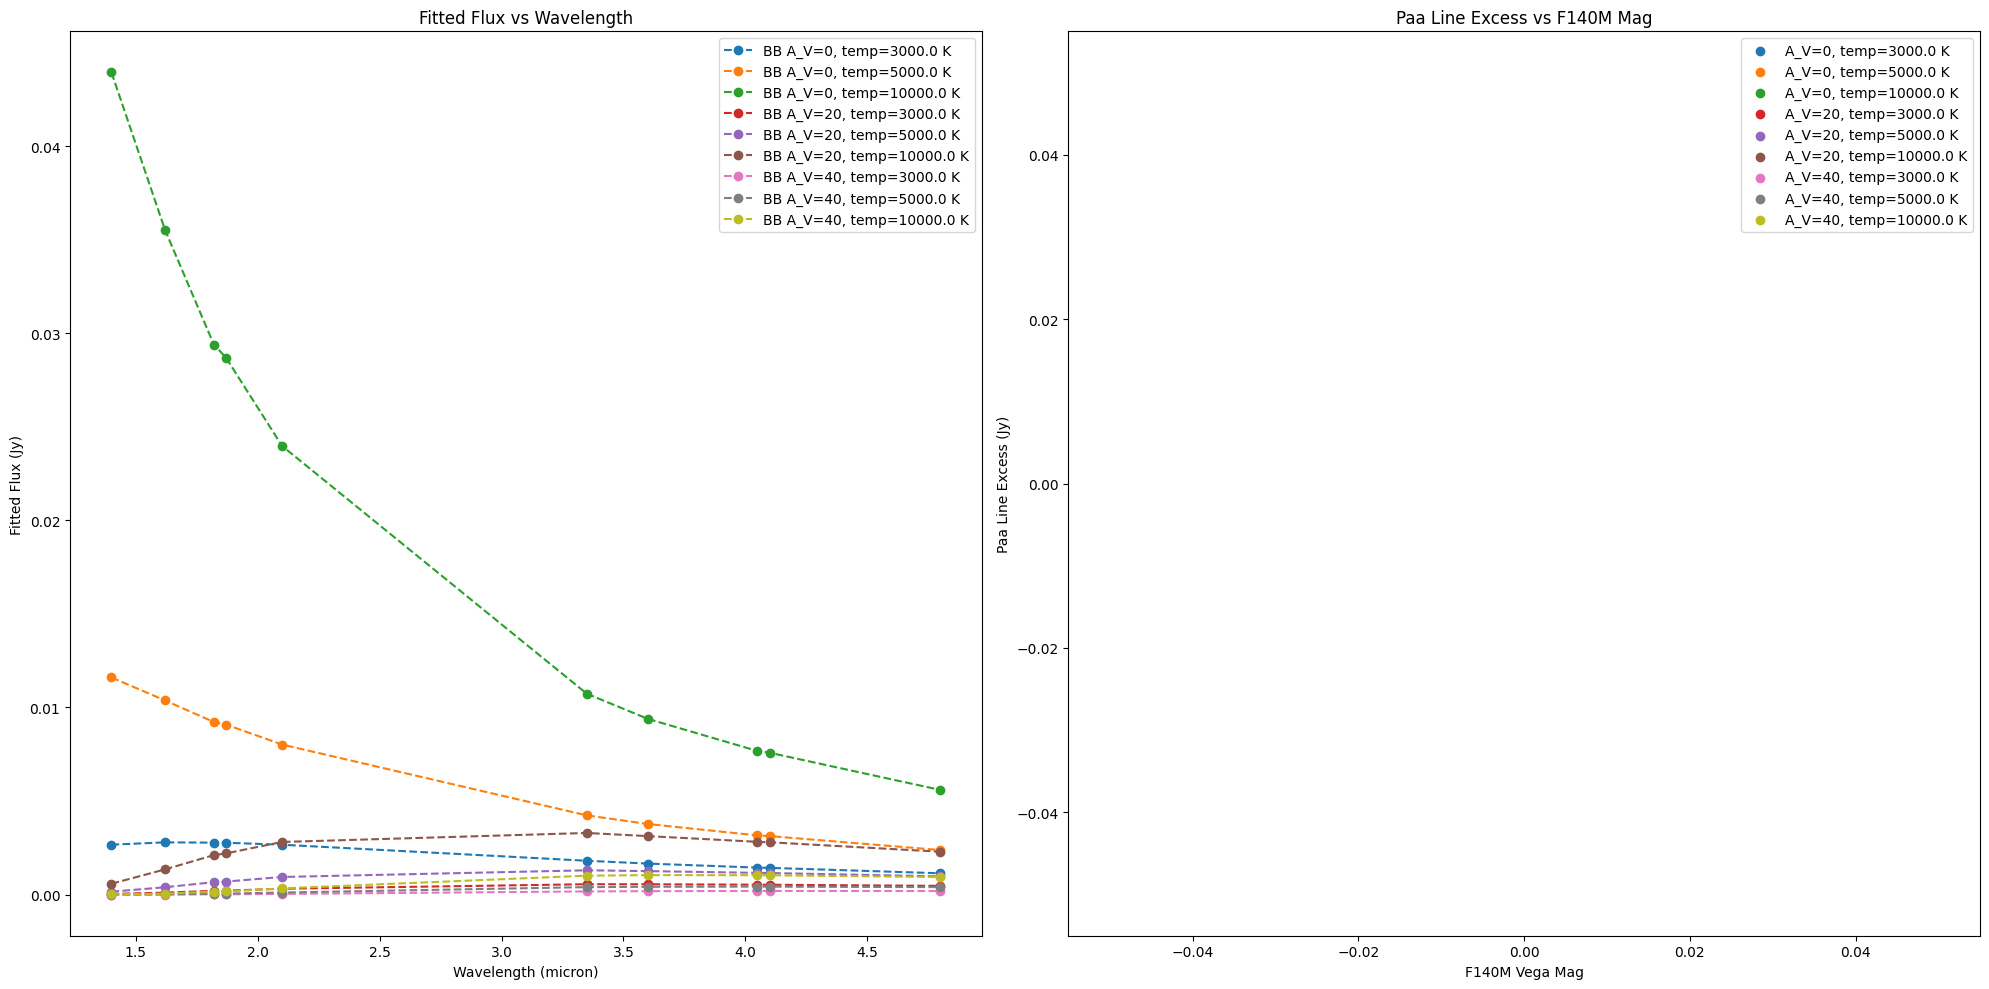

In [ ]:
A_V_list = [0, 20, 40]
temp_list = [3000*u.K, 5000*u.K, 10000*u.K]
fig = plt.figure(figsize=(20, 10))

ax1 = fig.add_subplot(1,2, 1)
ax2 = fig.add_subplot(1,2, 2)
cmap = plt.get_cmap('tab10')
color_index = 0
for A_V in A_V_list:
    for temp in temp_list:
        flux_bb_list = []
        wl_list = []
        for filtname_ in filternames:
            flux = get_flux(filtname_, A_V=A_V, temp=temp)

            # DEBUG: Call get_flux manually to inspect intermediate values
            from astropy.modeling.models import BlackBody
            from astroquery.svo_fps import SvoFps
            
            bb = BlackBody(temperature=temp)
            wave = np.linspace(1.3, 25.0, 1000) * u.micron
            I_nu = bb(wave)
            omega = np.pi * (10.0 * u.R_sun / 5.4 * u.kpc) ** 2 * u.sr
            F_nu = I_nu * omega
            F_nu_ext = F_nu * 10 ** (-0.4 * CT06_MWLoc()(wave) * A_V)
            
            inst = "NIRCam" if float(filtname_[1:-1]) < 500 else "MIRI"
            wavelength_table = SvoFps.get_transmission_data(f"JWST/{inst}.{filtname_.upper()}")
            waves_svo = np.asarray(wavelength_table["Wavelength"])
            trans_svo = np.asarray(wavelength_table["Transmission"])
            trans_interp = np.interp(wave.to_value(u.micron), waves_svo, trans_svo)
            
            print(f"{filtname_}: trans range=[{trans_interp.min():.2e}, {trans_interp.max():.2e}], " + 
                f"trans sum={trans_interp.sum():.2e}, flux={flux.value:.3e} Jy")
            
            flux_bb_list.append(flux.to_value(u.Jy))
            wl_list.append(float(filtname_[1:-1])/100)

            
        ax1.plot(wl_list, flux_bb_list, label=f"BB A_V={A_V}, temp={temp}", color=cmap(color_index), linestyle='dashed', marker='o')
        for wl_ in wl_list:
            subset = all_phot_result[
                (all_phot_result['A_V'] == A_V)
                & (all_phot_result['temp'] == temp)
                & (all_phot_result['wavelength'] == wl_)
            ]

            if len(subset) == 0:
                continue

            xvals = np.full(len(subset), wl_, dtype=float)
            yvals = np.asarray(subset['flux_fit'], dtype=float)  # already Jy-like numeric in your table
            ax1.scatter(xvals, yvals, label=f"A_V={A_V}, temp={temp}", color=cmap(color_index))
            print(f"Plotted {len(subset)} points for A_V={A_V}, temp={temp}, wavelength={wl_} micron")
            print('xvals', xvals)
            print('yvals', yvals)
        color_index += 1
ax1.set_xlabel('Wavelength (micron)')
ax1.set_ylabel('Fitted Flux (Jy)')
ax1.set_title('Fitted Flux vs Wavelength')
ax1.legend()

color_index = 0

for A_V in A_V_list:
    for temp in temp_list:
        subset = all_phot_result[(all_phot_result['A_V'] == A_V) & (all_phot_result['temp'] == temp) & (all_phot_result['wavelength'] == 140)]
        f140m_mag = subset['mag_fit']
        print(f"Found {len(subset)} points for A_V={A_V}, temp={temp}, wavelength=140 micron")
        subset = all_phot_result[(all_phot_result['A_V'] == A_V) & (all_phot_result['temp'] == temp) & (all_phot_result['wavelength'] == 187)]
        f187n_flux = subset['flux_fit']
        print(f"Found {len(subset)} points for A_V={A_V}, temp={temp}, wavelength=187 micron")
        subset = all_phot_result[(all_phot_result['A_V'] == A_V) & (all_phot_result['temp'] == temp) & (all_phot_result['wavelength'] == 182)]
        f182m_flux = subset['flux_fit']
        paa_excess = get_line_excess(f187n_flux, f182m_flux, narrow='f187n', wide='f182m')
        ax2.scatter(f140m_mag, paa_excess, label=f"A_V={A_V}, temp={temp}", color=cmap(color_index))
        color_index += 1
ax2.set_xlabel('F140M Vega Mag')
ax2.set_ylabel('Paa Line Excess (Jy)')
ax2.set_title('Paa Line Excess vs F140M Mag')
ax2.legend()
plt.tight_layout()
plt.show()

In [ ]:
print(all_phot_result['wavelength'] )
print(np.unique(all_phot_result['wavelength'] ))

wavelength
----------
     480.0
     480.0
     480.0
     480.0
     480.0
     480.0
     480.0
     480.0
     480.0
wavelength
----------
     480.0
